# 1. Introduction to pySIMDEUM
This section goes through basic usage examples. Available as a jupyter notebook and a wiki page.

## `House` data structure

In [1]:
import pysimdeum
import matplotlib.pyplot as plt

In [2]:
# Built a house (one-person household)
house = pysimdeum.built_house(house_type='one_person')
print(house)

House:
	id	=	3324d8e1-3300-4144-b16b-aff3f2c55b7b
	type	=	one_person
	user	=	1
	appliances	=	['WcNewSave', 'BathroomTap', 'KitchenTap', 'NormalShower', 'WashingMachine']


/Users/val.ismaili/DAA/pysimdeum/pysimdeum/core/utils.py:286: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.1667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  s.iloc[start:end] = intensity
/Users/val.ismaili/DAA/pysimdeum/pysimdeum/core/utils.py:342: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6723566666666668' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  discharge_pattern.loc[discharge_start:discharge_end - pd.Timedelta(seconds=1)] = discharge_rate # restrict range to not be inclusive of final timstamp as this would result in extra discharge
/Users/val.ismaili/DAA/pysimdeum/pysimdeum/core/utils.py:342: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '

In [3]:
# Show the inhabitants of a house
print("List of Users:")
print(house.users)

List of Users:
[User(id='user_1', gender='female', age='home_ad', job=False)]


In [4]:
# Show water end-use devices present in the house
print("List of Devices:")
print(house.appliances) 

List of Devices:
[WcNewSave(name='WcNewSave'), BathroomTap(name='BathroomTap'), KitchenTap(name='KitchenTap'), NormalShower(name='NormalShower'), WashingMachine(name='EndUse')]


In [5]:
# Build statistics from consumption
tot_cons = house.consumption.sum(['enduse', 'user']).sel(flowtypes='totalflow').mean(['patterns'])
print(tot_cons)

<xarray.DataArray (time: 86401)> Size: 691kB
array([0., 0., 0., ..., 0., 0., 0.])
Coordinates:
  * time       (time) datetime64[ns] 691kB 2025-03-26 ... 2025-03-27
    flowtypes  <U9 36B 'totalflow'


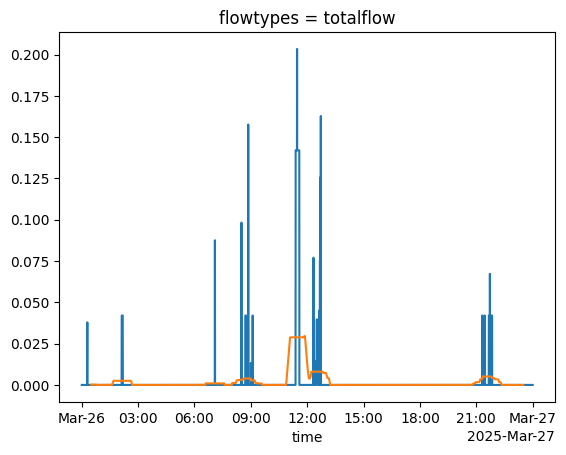

In [6]:
# Plot total consumption
tot_cons.plot()
tot_cons.rolling(time=3600, center=True).mean().plot()
plt.show()

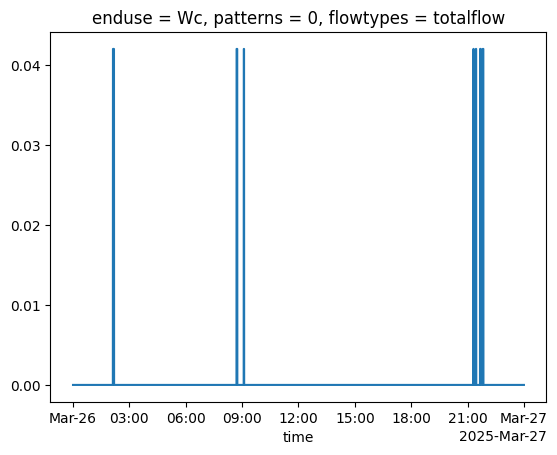

In [7]:
# Plot consumption for a specific end-use
house.consumption.sum(["user"]).sel(enduse="Wc").sel(flowtypes="totalflow").plot()